### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC

In [182]:
from imblearn.over_sampling import RandomOverSampler

### Step 2: Load Dataset

In [5]:
df = pd.read_csv('./data/loan_data.csv')

In [6]:
df.head()

,Loan_ID,Gender,Married,ApplicantIncome,LoanAmount,Loan_Status
0,LP001002,Male,No,5849,NaN,Y
1,LP001003,Male,Yes,4583,128.0,N
2,LP001005,Male,Yes,3000,66.0,Y
3,LP001006,Male,Yes,2583,120.0,Y
4,LP001008,Male,No,6000,141.0,Y


In [7]:
df.shape

(598, 6)

### Step 3: Exploring Data

In [8]:
df.describe()

,ApplicantIncome,LoanAmount
count,598.000000,577.000000
mean,5292.252508,144.968804
std,5807.265364,82.704182
min,150.000000,9.000000
25%,2877.500000,100.000000
50%,3806.000000,127.000000
75%,5746.000000,167.000000
max,81000.000000,650.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Loan_ID          598 non-null    object 
 1   Gender           598 non-null    object 
 2   Married          598 non-null    object 
 3   ApplicantIncome  598 non-null    int64  
 4   LoanAmount       577 non-null    float64
 5   Loan_Status      598 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 28.2+ KB


In [10]:
df.isnull().sum()

Loan_ID             0
Gender              0
Married             0
ApplicantIncome     0
LoanAmount         21
Loan_Status         0
dtype: int64

In [11]:
df.isna().sum()

Loan_ID             0
Gender              0
Married             0
ApplicantIncome     0
LoanAmount         21
Loan_Status         0
dtype: int64

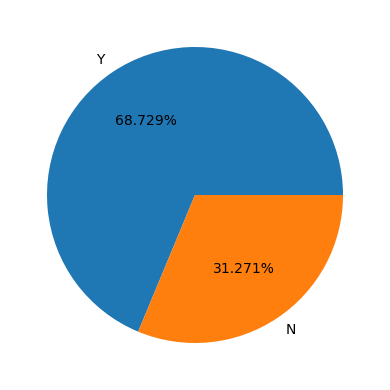

In [12]:
plt.figure(figsize=(6, 4))
plt.pie(
    df['Loan_Status'].value_counts().values,
    labels = df['Loan_Status'].value_counts().index,
    autopct='%1.3f%%'
)
plt.tight_layout()

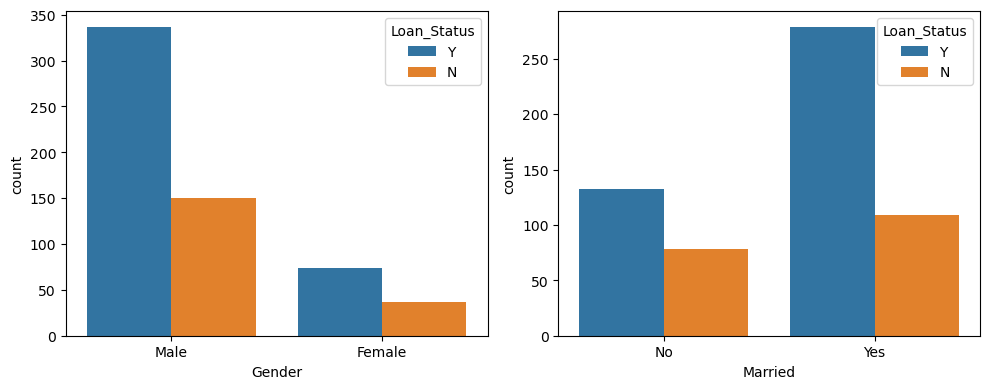

In [13]:
plt.figure(figsize=(10, 4))
for i, col in enumerate(['Gender', 'Married']):
    plt.subplot(1, 2, i+1)
    sns.countplot(x=col, hue='Loan_Status', data=df)
plt.tight_layout()

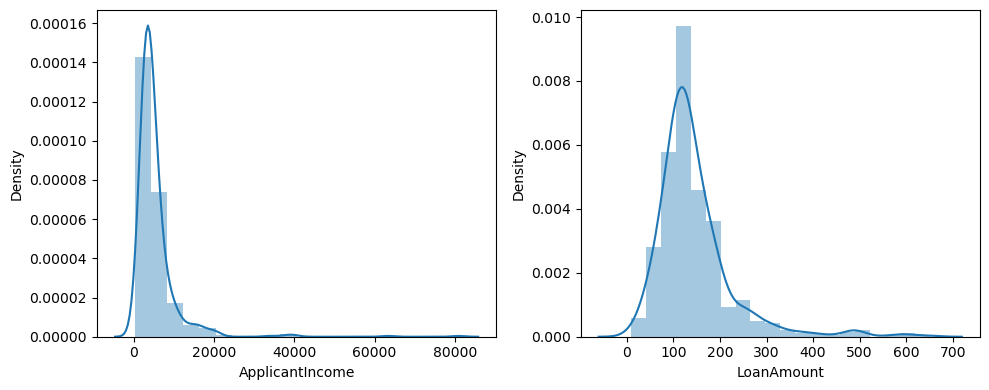

In [14]:
plt.figure(figsize=(10, 4))
for i, col in enumerate(['ApplicantIncome', 'LoanAmount']):
    plt.subplot(1, 2, i+1)
    sns.distplot(df[col], bins=20)
plt.tight_layout()

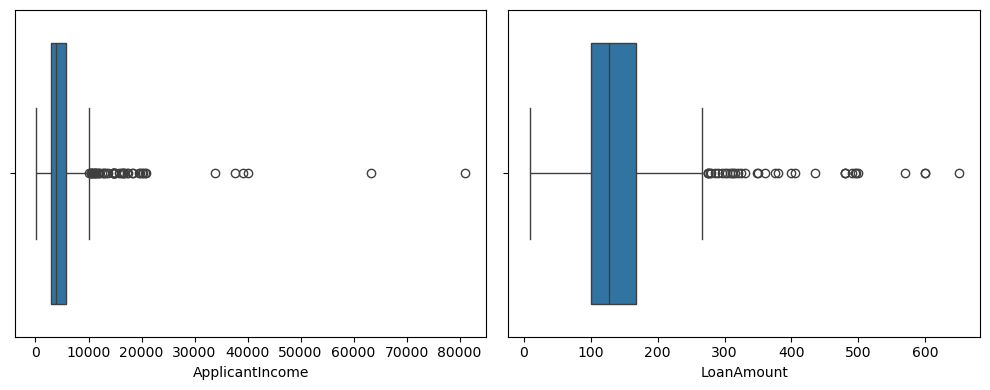

In [15]:
plt.figure(figsize=(10, 4))
for i, col in enumerate(['ApplicantIncome', 'LoanAmount']):
    plt.subplot(1, 2, i+1)
    sns.boxplot(df[col], orient='h')
plt.tight_layout()

In [17]:
df = df[df['ApplicantIncome'] < 25000]
df = df[df['LoanAmount'] < 400]

In [20]:
df.groupby('Gender').mean(numeric_only=True)

,ApplicantIncome,LoanAmount
Gender,,
Female,4385.579439,118.822430
Male,4652.502212,139.289823


In [21]:
df.groupby(['Married', 'Gender']).mean(numeric_only=True)

ApplicantIncome  LoanAmount
Married Gender                             
No      Female      4500.282051  116.115385
        Male        4682.057851  126.644628
Yes     Female      4077.068966  126.103448
        Male        4641.697885  143.912387

### Step 4: Feature Engineering

In [22]:
obj_list = df.select_dtypes(np.object_).columns
num_list = df.select_dtypes(np.number).columns

In [26]:
for num in num_list:
    scaler = StandardScaler()
    df[num] = scaler.fit_transform(df[[num]])

In [27]:
for obj in obj_list:
    le = LabelEncoder()
    df[obj] = le.fit_transform(df[obj])

<Axes: >

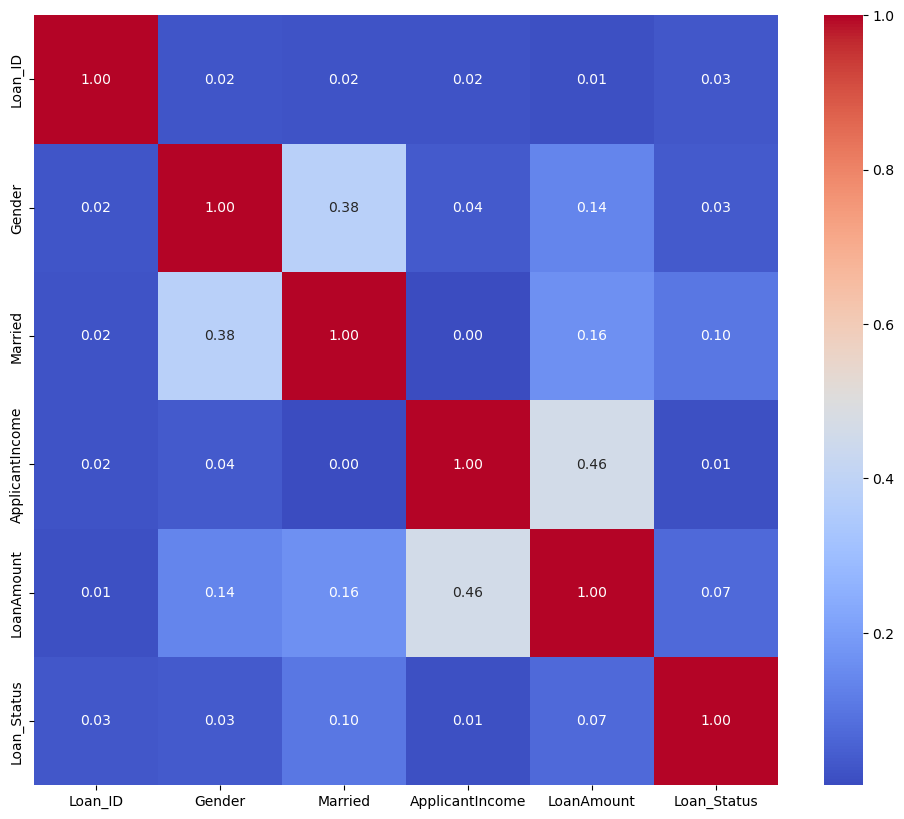

In [28]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    annot=True,
    fmt='.2f',
    cmap=plt.cm.coolwarm
)

### Step 5: Preparing Data

In [169]:
features = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
# features = df.drop(['Loan_Status'], axis=1)
target = df['Loan_Status']

In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [171]:
ros = RandomOverSampler(
    # sampling_strategy='minority',
    random_state=42
)

In [172]:
X_train, y_train = ros.fit_resample(X_train, y_train)

### Step 6: Building & Training Model

In [173]:
model = SVC(kernel='sigmoid')

In [174]:
model.fit(X_train, y_train)

,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Step 7: Evaluate Model

In [175]:
y_pred = model.predict(X_test)

In [176]:
print('Training Accuracy : ', round(metrics.accuracy_score(y_train, model.predict(X_train)), 3))
print('Validation Accuracy : ', round(metrics.accuracy_score(y_test, y_pred), 3))

Training Accuracy :  0.514
Validation Accuracy :  0.562


In [177]:
training_roc_auc = metrics.roc_auc_score(y_train, model.predict(X_train))
validation_roc_auc = metrics.roc_auc_score(y_test, y_pred)

In [178]:
print('Training ROC AUC Score:', round(training_roc_auc, 3))
print('Validation ROC AUC Score:', round(validation_roc_auc, 3))

Training ROC AUC Score: 0.514
Validation ROC AUC Score: 0.557


In [179]:
cm = metrics.confusion_matrix(y_test, y_pred)

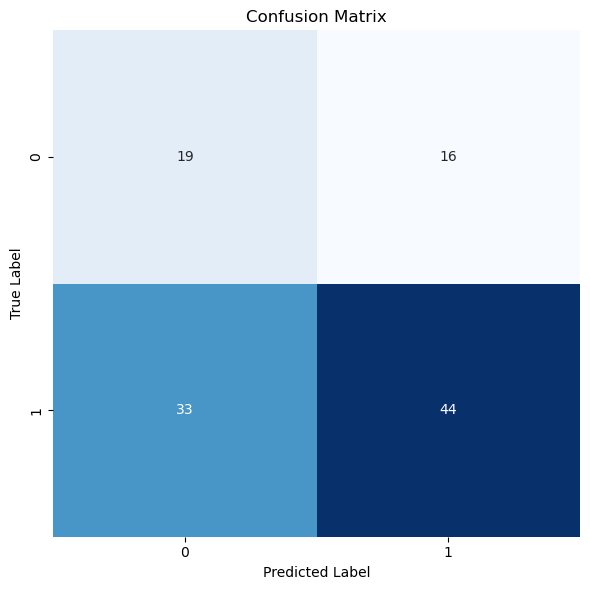

In [180]:
plt.figure(figsize=(6, 6))
sns.heatmap(
    cm,
    annot=True,
    cmap=plt.cm.Blues,
    cbar=False
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

In [181]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.37      0.54      0.44        35
           1       0.73      0.57      0.64        77

    accuracy                           0.56       112
   macro avg       0.55      0.56      0.54       112
weighted avg       0.62      0.56      0.58       112

